In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

In [2]:
GEFS = xr.open_dataset("NZ_GEFS/NZ_GEFS.nc")
time = GEFS.time[0]
GEFS = GEFS.sel(longitude=slice(165, 180), latitude=slice(-33,-48), time=time)
GEFS

<xarray.Dataset> Size: 45kB
Dimensions:    (latitude: 61, longitude: 60)
Coordinates:
  * latitude   (latitude) float64 488B -33.0 -33.25 -33.5 ... -47.5 -47.75 -48.0
  * longitude  (longitude) float64 480B 165.0 165.3 165.5 ... 179.3 179.5 179.8
    time       datetime64[ns] 8B 2000-01-08T03:00:00
Data variables:
    swh        (latitude, longitude) float32 15kB ...
    dirpw      (latitude, longitude) float32 15kB ...
    perpw      (latitude, longitude) float32 15kB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    model:                   gefs_wave_reforecast
    product:                 GEFSv12/wave_reforecast
    description:             NOAA Wave Ensemble Reforecast
    remote_grib:             https://noaa-nws-gefswaves-reforecast-pds.s3.ama...
    local_grib:              GEFS/gefs_wave_reforecast/20000108/subset_b4ef68...
    search:                  :(?:HTSGW|DIRPW|PERPW):surface:(?:anl|(?:3|6|9|1...

In [3]:
WHACS = xr.open_dataset("WHACS/hs_NZ/hs_WHACS_hindcast_WHACS_ERA5_1hr_200001010000-200001312300.nc").sel(time=time)
WHACS

<xarray.Dataset> Size: 348kB
Dimensions:                      (seapoint: 17422)
Coordinates:
  * seapoint                     (seapoint) int32 70kB 530569 530570 ... 951522
    time                         datetime64[ns] 8B 2000-01-08T03:00:00
Data variables:
    hs                           (seapoint) float64 139kB ...
    longitude                    (seapoint) float32 70kB ...
    latitude                     (seapoint) float32 70kB ...
    projected_coordinate_system  int32 4B ...
Attributes: (12/59)
    Conventions:                     CF-1.11 ACDD-1.3
    title:                           Wave Hindcast for the Australian Climate...
    summary:                         Wave Hindcast for the Australian Climate...
    keywords:                        WHACS, ACS, waves, ocean, coast, WWIII, ...
    id:                              BoM-CSIRO-WHACS-001
    naming_authority:                au.csiro
    ...                              ...
    geospatial_lon_max:              179.9375
    geospatial_vertical_positive:    up
    time_coverage_start:             2000-01-01T00:00:00
    time_coverage_end:               2000-01-31T23:00:00
    time_coverage_duration:          P30DT23H0M0S
    time_coverage_resolution:        P0DT1H0M0S

In [4]:
import pandas as pd
pd.Series(pd.Series(WHACS.latitude.values).unique()).diff().value_counts()

 0.06250    226
 0.12500    118
-7.96875      1
 0.15625      1
-6.15625      1
Name: count, dtype: int64

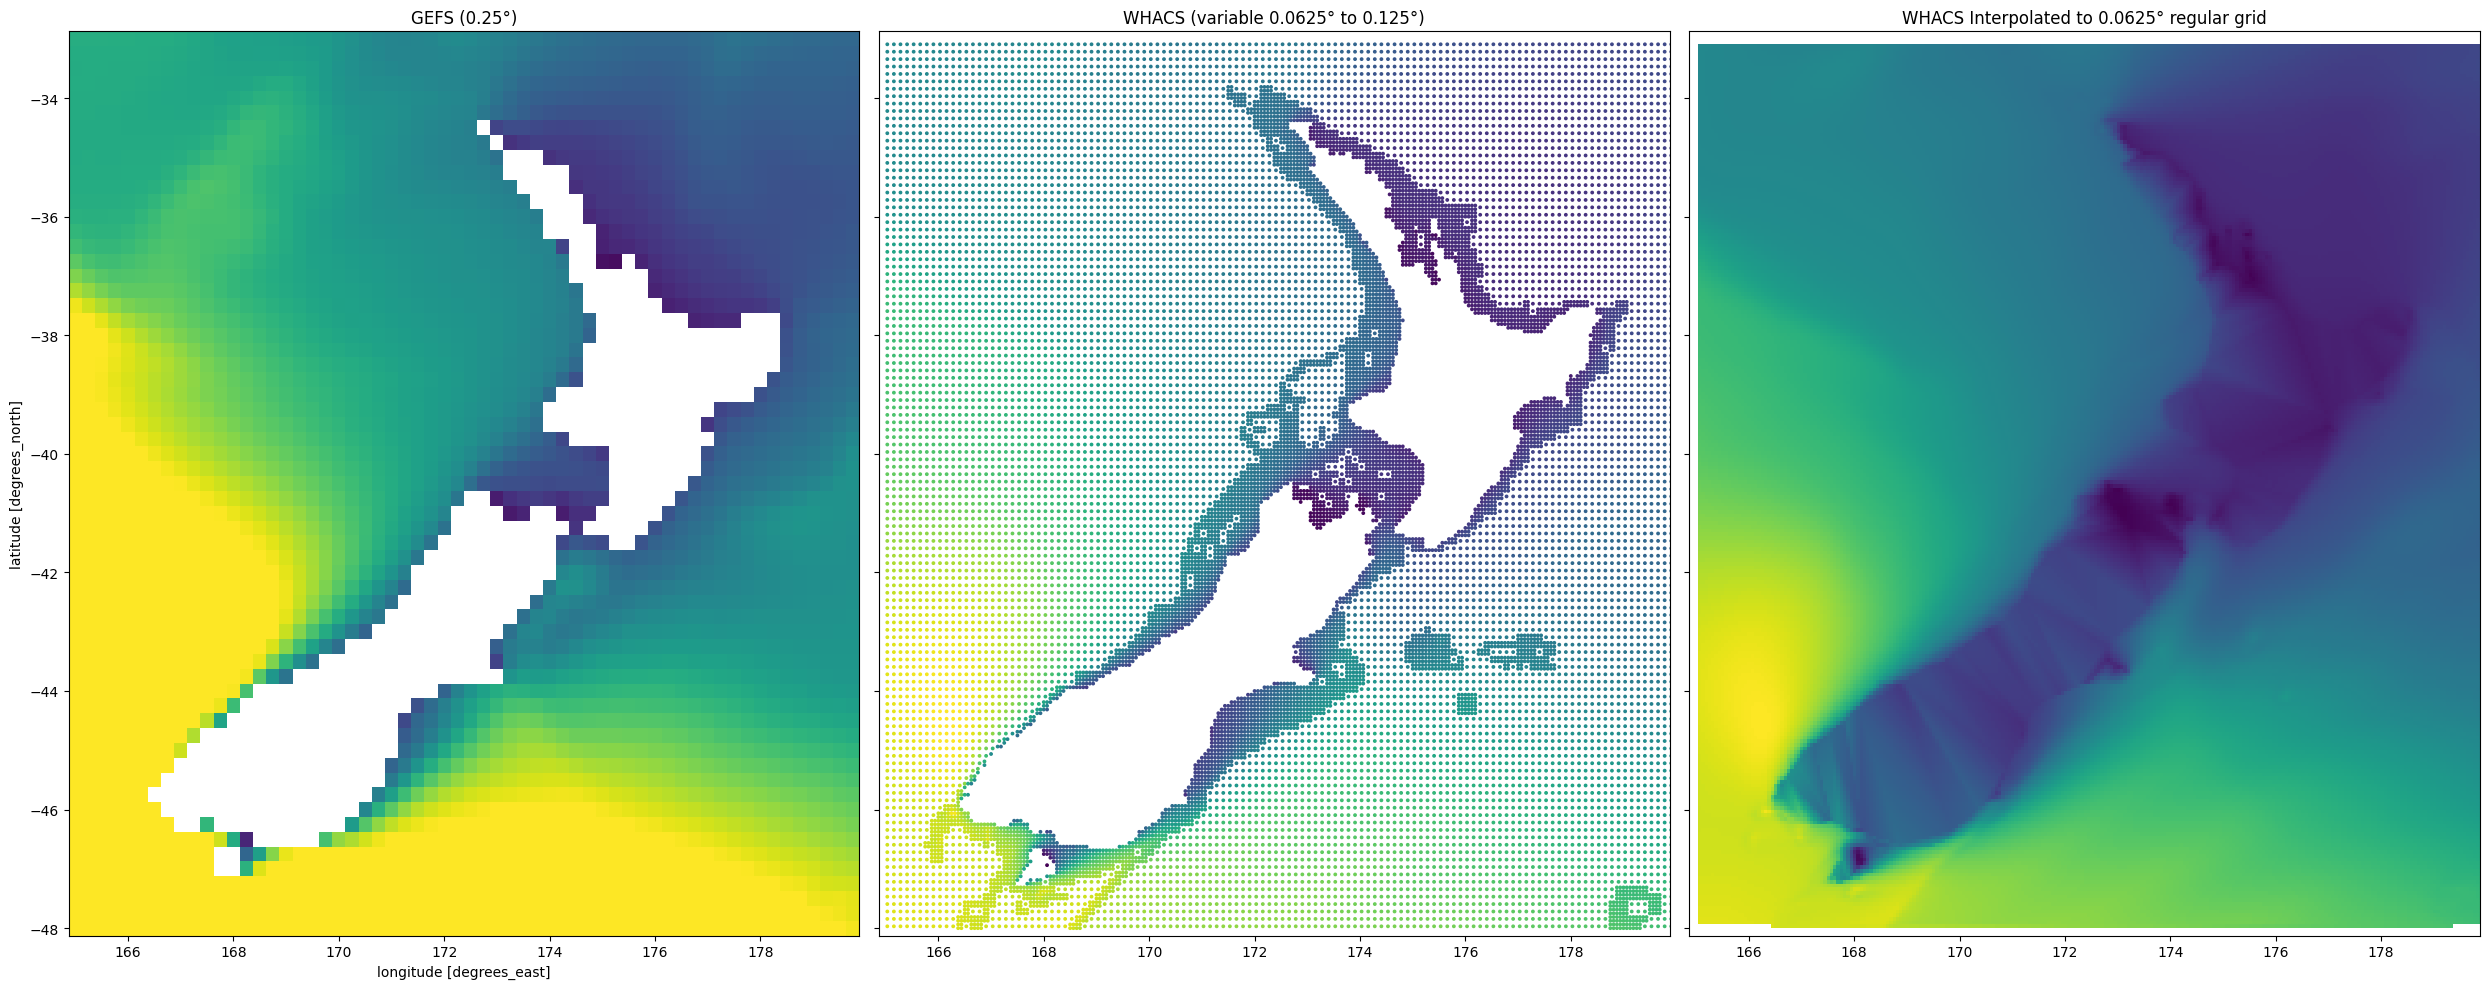

In [5]:
fig, [ax1, ax2, ax3] = plt.subplots(nrows=1, ncols=3, figsize=(25, 10), sharex=True, sharey=True)
GEFS.swh.plot(ax=ax1, vmin=0, vmax=3,add_colorbar=False)
ax2.scatter(WHACS.longitude, WHACS.latitude, c=WHACS.hs, cmap='viridis', s=3)
grid_x, grid_y = np.meshgrid(
    np.arange(float(WHACS.longitude.min()), float(WHACS.longitude.max()), 0.06250),
    np.arange(float(WHACS.latitude.min()), float(WHACS.latitude.max()),   0.06250)
)
grid_z_linear = griddata(
    points=(WHACS.longitude, WHACS.latitude),
    values=WHACS.hs,
    xi=(grid_x, grid_y),
    method='linear'
)
ax3.imshow(
    grid_z_linear,
    extent=(float(WHACS.longitude.min()), float(WHACS.longitude.max()), float(WHACS.latitude.min()), float(WHACS.latitude.max())),
    origin='lower',
    cmap='viridis',
    aspect='auto'
)
ax1.title.set_text("GEFS (0.25°)")
ax2.title.set_text("WHACS (variable 0.0625° to 0.125°)")
ax3.title.set_text("WHACS Interpolated to 0.0625° regular grid")
plt.tight_layout()
plt.show()